# Detecção de Fraudes em Transações de Cartão de Crédito

## Objetivo

Este projeto tem como objetivo desenvolver modelos de Machine Learning
para identificar possíveis transações fraudulentas em cartões de crédito.

O principal desafio do problema é o forte desbalanceamento das classes:
a grande maioria das transações é legítima e uma pequena parcela corresponde
a fraudes.

Por esse motivo, a acurácia não será utilizada como principal métrica de
avaliação. O foco será principalmente no recall da classe de fraude,
considerando também precisão e F1-score.

Neste projeto serão comparados três modelos:

- Regressão Logística
- Random Forest
- XGBoost

Ao final, também será realizado o ajuste do limiar de decisão e uma
análise de explicabilidade utilizando SHAP.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

import shap

import warnings
warnings.filterwarnings("ignore")

## 1. Exploração dos dados

Carregamento do dataset disponibilizado na aula para
sua estrutura.

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Verificação de valores ausentes

Antes de iniciar o treinamento, verificação de valores
ausentes no dataset.

In [6]:
df.isnull().sum().sum()

np.int64(0)

### Distribuição das classes

A coluna `Class` representa a variável que quero prever:

- `0` = transação normal
- `1` = fraude

Verificar como essas classes estão distribuídas.

In [7]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [8]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


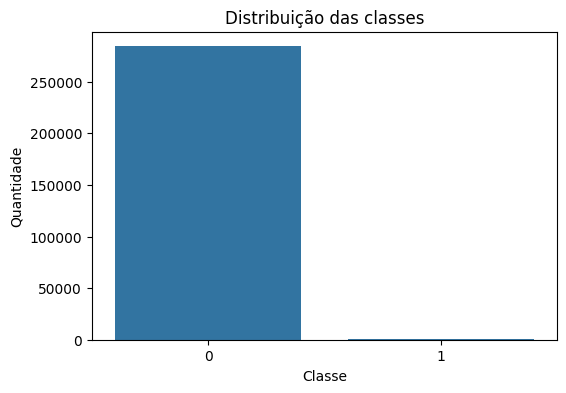

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Class")

plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

### Análise do desbalanceamento

A classe 0 representa praticamente todas as transações do conjunto,
enquanto a classe 1 representa apenas uma pequena parcela.

Esse desbalanceamento faz com que a acurácia seja uma métrica pouco
adequada para analisar o desempenho do modelo.

Por exemplo, um modelo que classificasse praticamente todas as transações
como normais poderia apresentar uma acurácia muito alta mesmo deixando
passar grande parte das fraudes.

Por isso, neste projeto o recall da classe de fraude será uma das
principais métricas observadas.

## 2. Preparação dos dados

A variável `Amount` representa o valor da transação.

Como os valores podem apresentar uma distribuição muito diferente,
será criada uma nova variável utilizando transformação logarítmica.

A função `log1p` corresponde a `log(1 + x)` e permite trabalhar também
com valores iguais a zero.

In [10]:
df["LogAmount"] = np.log1p(df["Amount"])

df[["Amount", "LogAmount"]].head()

,Amount,LogAmount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


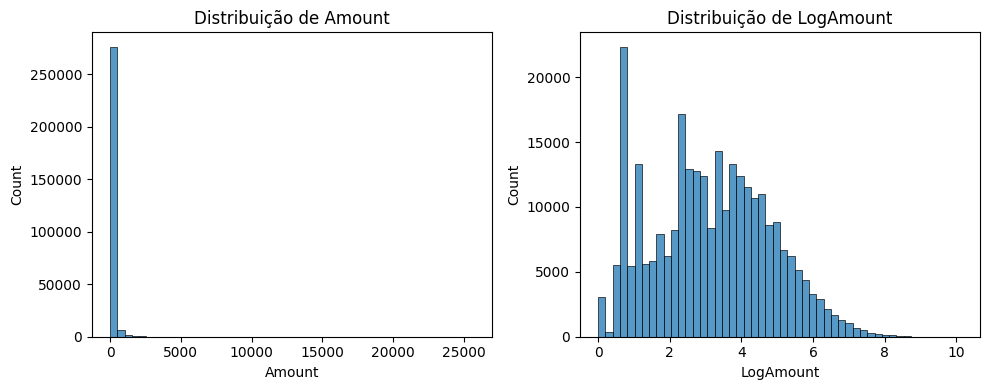

In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["Amount"], bins=50)
plt.title("Distribuição de Amount")

plt.subplot(1, 2, 2)
sns.histplot(df["LogAmount"], bins=50)
plt.title("Distribuição de LogAmount")

plt.tight_layout()
plt.show()

In [12]:
X = df.drop(columns=["Class", "Amount"])
y = df["Class"]

X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,LogAmount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539


### Separação dos dados

Os dados serão divididos em:

- 60% para treinamento
- 20% para validação
- 20% para teste

Será utilizado `stratify=y` para manter uma proporção semelhante de
transações normais e fraudulentas nas diferentes partes do dataset.

O conjunto de validação será utilizado posteriormente para analisar
diferentes limiares de decisão.

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (170884, 30)
Validação: (56961, 30)
Teste: (56962, 30)


In [14]:
print("Fraudes no treino:", y_train.sum())
print("Fraudes na validação:", y_val.sum())
print("Fraudes no teste:", y_test.sum())

Fraudes no treino: 295
Fraudes na validação: 98
Fraudes no teste: 99


### Padronização das variáveis

Agora será utilizado o `StandardScaler`.

O scaler será ajustado somente com os dados de treinamento e depois
aplicado aos dados de validação e teste.

Dessa forma, evitamos utilizar informações do conjunto de teste durante
a preparação dos dados.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Peso das classes

Como a classe de fraude é muito menor que a classe normal, os modelos
podem ter dificuldade para aprender a identificar a classe minoritária.

Para reduzir esse problema, utilizarei pesos de classe nos modelos
que possuem esse recurso.

Assim, erros cometidos na classe de fraude terão maior importância
durante o treinamento.

## 3. Treinamento dos modelos

### Regressão Logística

A Regressão Logística será utilizada como modelo baseline.

A ideia é começar com um modelo relativamente simples para ter uma
referência antes de utilizar modelos baseados em árvores.

In [16]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [17]:
y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56863
           1       0.06      0.91      0.11        99

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962



### Random Forest

O segundo modelo utilizado será o Random Forest.

Esse algoritmo combina várias árvores de decisão e pode capturar
relações não lineares entre as variáveis.

Também será utilizado `class_weight="balanced"` para considerar o
desbalanceamento das classes.

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [19]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.99      0.75      0.85        99

    accuracy                           1.00     56962
   macro avg       0.99      0.87      0.93     56962
weighted avg       1.00      1.00      1.00     56962



### XGBoost

O terceiro modelo será o XGBoost.

Como existe um forte desbalanceamento entre as classes, será utilizado
`scale_pos_weight` para dar maior peso à classe de fraude.

In [20]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

scale_pos_weight

np.float64(578.2677966101695)

In [21]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.74      0.85      0.79        99

    accuracy                           1.00     56962
   macro avg       0.87      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [23]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Random Forest",
        "XGBoost"
    ],
    "Precisão": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

resultados.sort_values("Recall", ascending=False)

,Modelo,Precisão,Recall,F1,ROC-AUC
0,Regressão Logística,0.060811,0.909091,0.113996,0.966646
2,XGBoost,0.736842,0.848485,0.788732,0.973811
1,Random Forest,0.986667,0.747475,0.850575,0.953266


## 4. Avaliação dos modelos

A matriz de confusão permite observar os acertos e erros do modelo
para cada classe.

No problema de fraude, o interesse é principalmente em identificar
quantas fraudes foram encontradas e quantas passaram despercebidas.

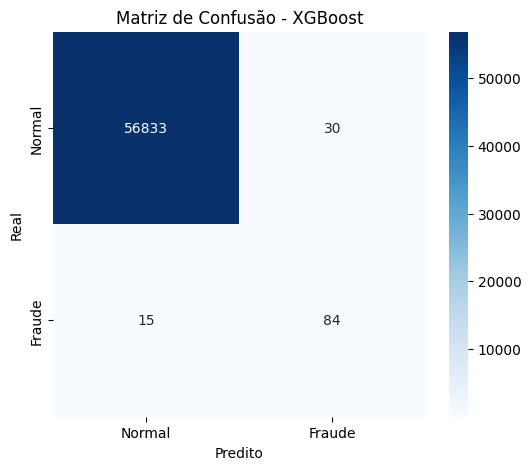

In [24]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraude"],
    yticklabels=["Normal", "Fraude"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - XGBoost")

plt.show()

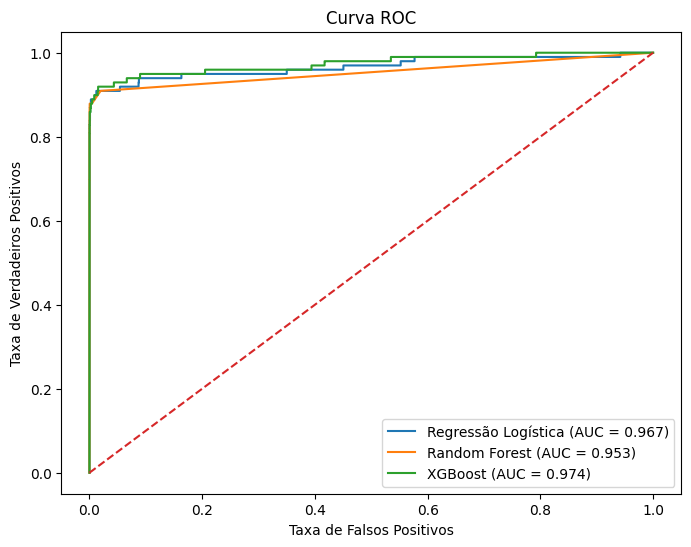

In [25]:
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Regressão Logística (AUC = {roc_auc_score(y_test, y_prob_logistic):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC")
plt.legend()

plt.show()

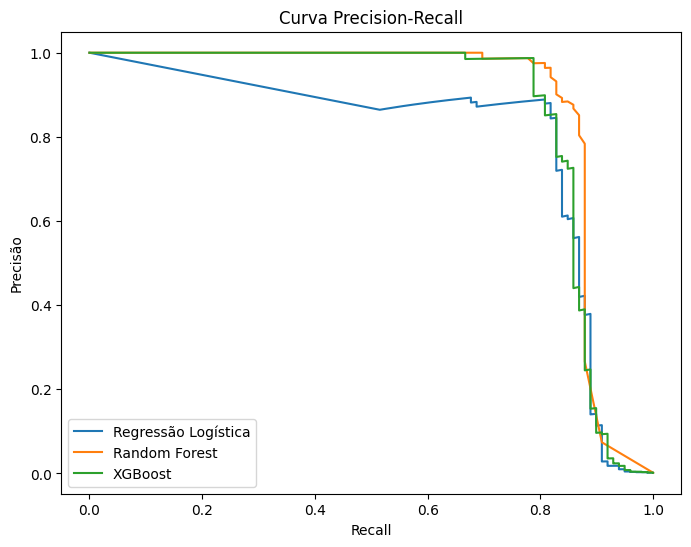

In [26]:
precision_logistic, recall_logistic, _ = precision_recall_curve(
    y_test, y_prob_logistic
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test, y_prob_rf
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test, y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_logistic,
    precision_logistic,
    label="Regressão Logística"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precision-Recall")
plt.legend()

plt.show()

### Ajuste do limiar de decisão

Por padrão, um classificador costuma considerar uma transação como
fraudulenta quando a probabilidade prevista é maior ou igual a 0,5.

Porém, em um problema de fraude, pode-se utilizar um limiar diferente
para tentar identificar uma quantidade maior de fraudes.

Para evitar utilizar o conjunto de teste nessa escolha, analisarei
os limiares utilizando o conjunto de validação.

In [28]:
# Treino novamente o XGBoost já utilizado anteriormente.
# A previsão será feita no conjunto de validação.

y_prob_xgb_val = xgb_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb_val >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.05,0.173469,0.867347,0.289116
1,0.10,0.309091,0.867347,0.455764
2,0.15,0.395238,0.846939,0.538961
3,0.20,0.485380,0.846939,0.617100
4,0.25,0.528662,0.846939,0.650980
5,0.30,0.546667,0.836735,0.661290
6,0.35,0.585714,0.836735,0.689076
7,0.40,0.640625,0.836735,0.725664
8,0.45,0.637795,0.826531,0.720000
9,0.50,0.669421,0.826531,0.739726


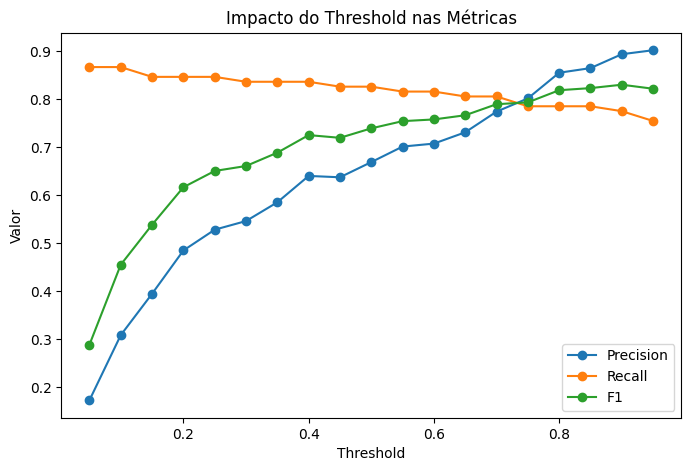

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"

)

plt.xlabel("Threshold")
plt.ylabel("Valor")
plt.title("Impacto do Threshold nas Métricas")
plt.legend()

plt.show()

In [30]:
threshold_candidates = threshold_df[
    threshold_df["Recall"] >= 0.80
]

threshold_candidates

,Threshold,Precision,Recall,F1
0,0.05,0.173469,0.867347,0.289116
1,0.10,0.309091,0.867347,0.455764
2,0.15,0.395238,0.846939,0.538961
3,0.20,0.485380,0.846939,0.617100
4,0.25,0.528662,0.846939,0.650980
5,0.30,0.546667,0.836735,0.661290
6,0.35,0.585714,0.836735,0.689076
7,0.40,0.640625,0.836735,0.725664
8,0.45,0.637795,0.826531,0.720000
9,0.50,0.669421,0.826531,0.739726


In [31]:
if len(threshold_candidates) > 0:
    best_threshold = threshold_candidates.sort_values(
        "Precision",
        ascending=False
    ).iloc[0]["Threshold"]
else:
    best_threshold = threshold_df.sort_values(
        "F1",
        ascending=False
    ).iloc[0]["Threshold"]

best_threshold

np.float64(0.7000000000000001)

### Threshold escolhido

O threshold foi escolhido utilizando apenas o conjunto de validação.

A regra utilizada foi buscar um recall de pelo menos 80% e, entre os
thresholds que atingiram esse objetivo, escolher aquele que apresentou
maior precisão.

Caso nenhum threshold atingisse 80% de recall, foi utilizado como
alternativa o threshold com maior F1-score.

In [32]:
y_pred_xgb_adjusted = (
    y_prob_xgb >= best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_xgb_adjusted,
        target_names=["Normal", "Fraude"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
      Fraude       0.82      0.83      0.82        99

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [34]:
# Comparando threshold padrão × ajustado

comparison_threshold = pd.DataFrame({
    "Métrica": ["Precision", "Recall", "F1"],
    "Threshold 0.50": [
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb)
    ],
    f"Threshold {best_threshold:.2f}": [
        precision_score(y_test, y_pred_xgb_adjusted),
        recall_score(y_test, y_pred_xgb_adjusted),
        f1_score(y_test, y_pred_xgb_adjusted)
    ]
})

comparison_threshold

,Métrica,Threshold 0.50,Threshold 0.70
0,Precision,0.736842,0.820000
1,Recall,0.848485,0.828283
2,F1,0.788732,0.824121


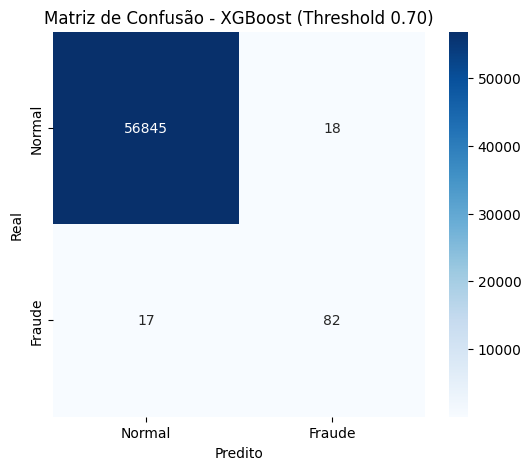

In [35]:
# Nova matriz de confusão

cm_adjusted = confusion_matrix(
    y_test,
    y_pred_xgb_adjusted
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_adjusted,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraude"],
    yticklabels=["Normal", "Fraude"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title(f"Matriz de Confusão - XGBoost (Threshold {best_threshold:.2f})")

plt.show()

## 5. Explicabilidade do modelo

Além de prever uma transação como fraude ou não fraude, é importante
entender quais variáveis tiveram maior influência no modelo.

Primeiro observar a importância das variáveis fornecida pelo
próprio XGBoost.

In [36]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,V14,0.449924
10,V10,0.055995
4,V4,0.051542
20,V20,0.038201
8,V8,0.032145
29,LogAmount,0.031226
19,V19,0.026485
12,V12,0.025073
21,V21,0.022320
26,V26,0.020524


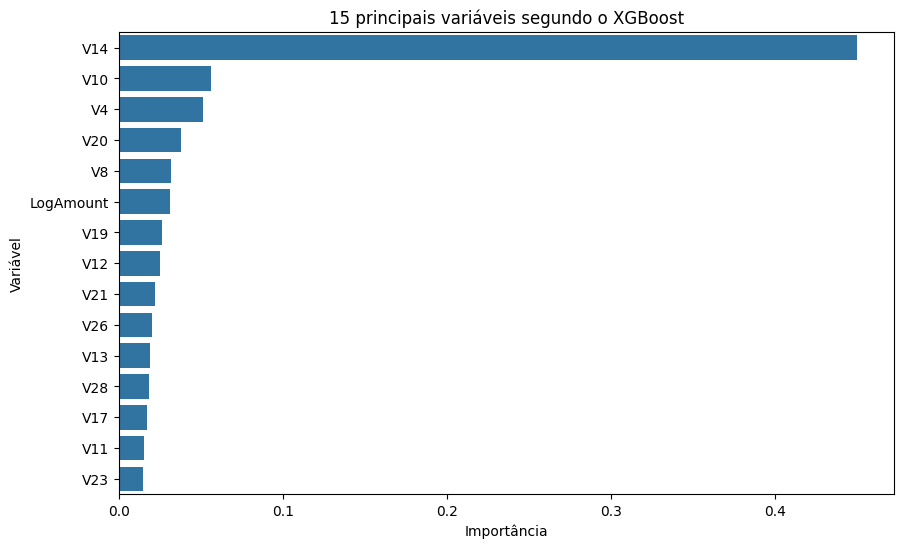

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("15 principais variáveis segundo o XGBoost")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()

### SHAP

SHAP é utilizado para ajudar a explicar as decisões do modelo.

Neste projeto vamos utilizar o `TreeExplainer`, adequado para modelos
baseados em árvores, como o XGBoost.

Para reduzir o tempo de processamento, será utilizada uma amostra dos
dados de teste.

In [38]:
X_shap = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X_shap)

shap_values

.values =
array([[-0.48416522, -0.9020496 , -0.12165163, ..., -0.18478933,
        -0.10557233,  0.16996579],
       [-0.46891582, -1.0074495 , -0.02646382, ...,  0.08963174,
        -0.06574692, -0.38304755],
       [-0.37633315, -0.18450281, -0.28158426, ...,  0.03647013,
        -0.21911833, -0.4216765 ],
       ...,
       [-0.2141    ,  0.00650606, -0.21652423, ..., -0.00782764,
        -0.14818124, -0.41668954],
       [-0.25596994, -1.2939712 ,  0.13354515, ..., -0.02645695,
        -0.13295864, -0.14285184],
       [-0.55405694, -0.2082105 ,  0.09201612, ..., -0.06525811,
        -0.16912912, -0.298671  ]], dtype=float32)

.base_values =
array([1.5507703, 1.5507703, 1.5507703, 1.5507703, 1.5507703, 1.5507703,
       1.5507703, 1.5507703, 1.5507703, 1.5507703, 1.5507703, 1.5507703,
       1.5507703, 1.5507703, 1.5507703, 1.5507703, 1.5507703, 1.5507703,
       1.5507703, 1.5507703, 1.5507703, 1.5507703, 1.5507703, 1.5507703,
       1.5507703, 1.5507703, 1.5507703, 1.5507703, 1.5

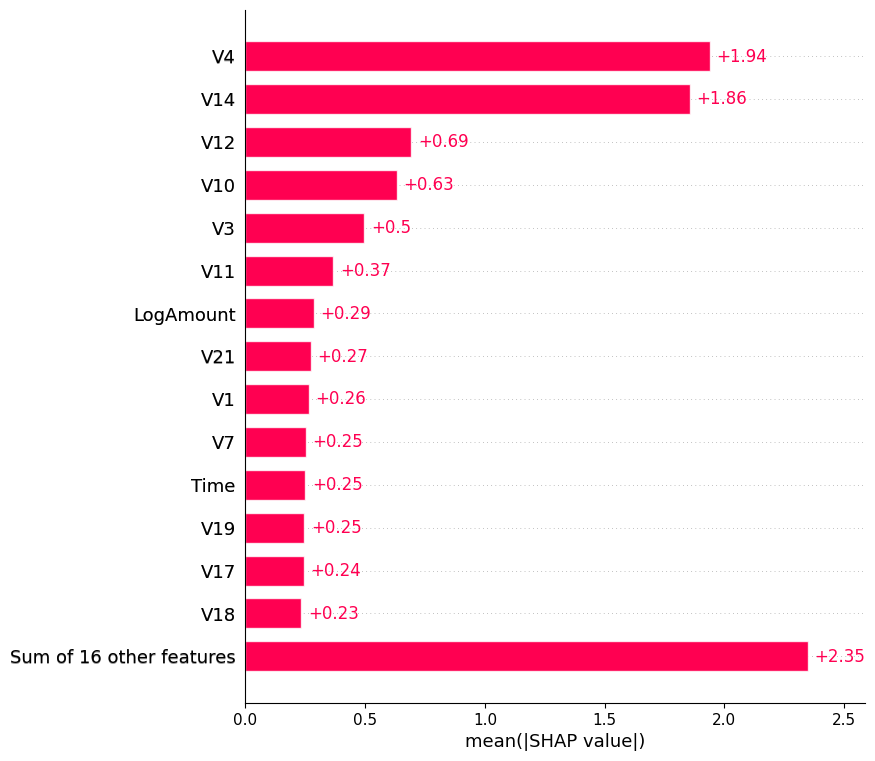

In [40]:
# Importância global com SHAP

shap.plots.bar(shap_values, max_display=15)

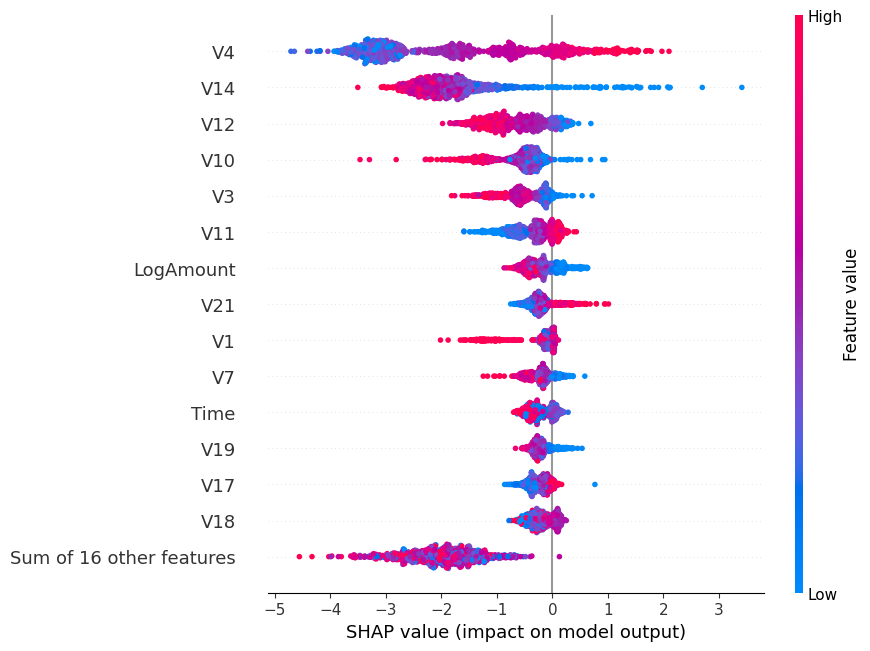

In [41]:
shap.plots.beeswarm(shap_values, max_display=15)

In [45]:
# Procurando uma transação de fraude dentro da amostra utilizada pelo SHAP

probabilidades_shap = xgb_model.predict_proba(X_shap)[:, 1]

indices_fraude_shap = np.where(
    probabilidades_shap >= best_threshold
)[0]

if len(indices_fraude_shap) > 0:
    indice = indices_fraude_shap[0]

    probabilidade = probabilidades_shap[indice]

    print(f"Probabilidade prevista de fraude: {probabilidade:.2%}")
else:
    indice = np.argmax(probabilidades_shap)

    probabilidade = probabilidades_shap[indice]

    print(
        f"Nenhuma fraude foi encontrada na amostra. "
        f"Será explicada a transação com maior probabilidade: "
        f"{probabilidade:.2%}"
    )

Probabilidade prevista de fraude: 99.98%


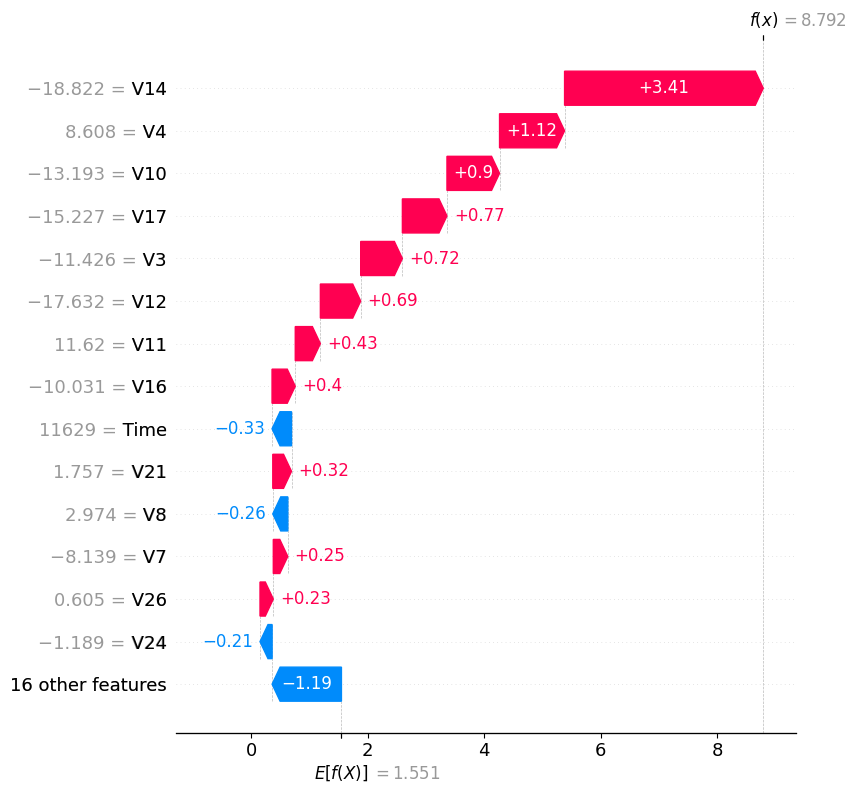

In [47]:
shap.plots.waterfall(
    shap_values[indice],
    max_display=15
)

### Interpretação do SHAP

Para a transação analisada, o modelo estimou uma probabilidade de
99,98% de fraude.

O gráfico de waterfall mostra como cada variável contribuiu para essa
previsão. As barras vermelhas representam contribuições que aumentaram
a saída do modelo em direção à classe de fraude, enquanto as barras
azuis representam contribuições que reduziram essa saída.

Entre as variáveis apresentadas, V14 teve a maior contribuição positiva
(+3,41), seguida por V4 (+1,12), V10 (+0,90) e V17 (+0,77).

Algumas variáveis contribuíram no sentido contrário, como Time (-0,33),
V8 (-0,26) e V24 (-0,21).

Como as variáveis V1 a V28 são transformações obtidas por PCA, seus
nomes não permitem uma interpretação direta de características do
comportamento da transação. Portanto, a análise deve ser entendida como
uma explicação da decisão do modelo, e não como uma interpretação de
negócio dessas variáveis.

# Conclusão

Neste projeto foi desenvolvido um pipeline de Machine Learning para
detecção de fraudes em transações de cartão de crédito.

O primeiro ponto observado foi o forte desbalanceamento da base. Como
as fraudes representam uma pequena parcela das transações, a acurácia
não foi utilizada como principal critério para escolha do modelo.

Foram treinados três modelos:

- Regressão Logística;
- Random Forest;
- XGBoost.

Os modelos foram comparados utilizando principalmente recall, além de
precision, F1-score e ROC-AUC.

Também foi realizado o ajuste do threshold de decisão. Em vez de
utilizar obrigatoriamente o valor padrão de 0,50, foram testados
diferentes limiares utilizando o conjunto de validação.

Essa etapa mostrou que a alteração do threshold modifica o equilíbrio
entre recall e precision. Em um problema de fraude, aumentar o recall
pode permitir a identificação de mais transações fraudulentas, mas
também pode aumentar a quantidade de falsos positivos.

Por fim, foi utilizada a biblioteca SHAP para entender quais variáveis
mais contribuíram para as previsões do modelo.

Como melhoria futura, seria possível testar outras estratégias para o
desbalanceamento, realizar uma busca mais ampla de hiperparâmetros e
criar novas variáveis relacionadas ao comportamento das transações.

# Diferenças em relação à abordagem apresentada na aula

Neste projeto, além de seguir o pipeline apresentado pela Expert, foram
realizadas algumas adaptações:

1. Foi criada uma etapa de validação separada do conjunto de teste para
   auxiliar na escolha do threshold.

2. O threshold foi analisado em diferentes valores para observar o
   impacto sobre precision, recall e F1-score.

3. Os resultados dos três modelos foram organizados em uma tabela para
   facilitar a comparação.

4. Foi realizada uma análise adicional utilizando a curva
   Precision-Recall.

5. A explicabilidade foi complementada com uma análise global e uma
   explicação individual utilizando SHAP.

Essas alterações foram feitas para tornar o processo de avaliação mais
claro e evitar que a escolha do threshold fosse feita diretamente sobre
os dados de teste.

# Resumo dos resultados

A tabela abaixo apresenta os resultados dos modelos avaliados.

A métrica de maior atenção neste projeto é o recall da classe de fraude,
mas precision e F1-score também foram consideradas para analisar o
equilíbrio entre identificação de fraudes e falsos positivos.

In [44]:
resultados

,Modelo,Precisão,Recall,F1,ROC-AUC
0,Regressão Logística,0.060811,0.909091,0.113996,0.966646
1,Random Forest,0.986667,0.747475,0.850575,0.953266
2,XGBoost,0.736842,0.848485,0.788732,0.973811
